In [51]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
data = pd.read_csv(r'C:\Users\Me\Downloads\Data_Internship\project_1\data_files\data.csv')
print(data.head())


                                           prod_name prc_before_dsc  \
0                             Shaan Body Milk 300 ml     EGP 230.00   
1   Starville Acne Prone Skin Facial Cleanser 400 ml     EGP 225.00   
2                   Clary Hair Leave In Cream 300 gm     EGP 340.00   
3  Garnier Micellar Water Face Cleanser & Daily M...     EGP 300.00   
4  NIVEA Black & White Invisible Original Antiper...     EGP 100.00   

  prc_after_dsc dsc_percentage   prod_review  
0    EGP 165.00            28%  4.4 out of 5  
1    EGP 149.00            34%  4.6 out of 5  
2    EGP 249.00            27%    4 out of 5  
3    EGP 239.00            20%  4.4 out of 5  
4     EGP 69.00            31%  4.4 out of 5  


In [53]:
print(data.info())
print(data.shape)
print(data.dtypes)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   prod_name       4080 non-null   object
 1   prc_before_dsc  3984 non-null   object
 2   prc_after_dsc   4080 non-null   object
 3   dsc_percentage  3984 non-null   object
 4   prod_review     3758 non-null   object
dtypes: object(5)
memory usage: 159.5+ KB
None
(4080, 5)
prod_name         object
prc_before_dsc    object
prc_after_dsc     object
dsc_percentage    object
prod_review       object
dtype: object


# Exploring null values and duplicates

In [54]:
cols_with_null_values=[]

for col in data.columns:
    print(f'percentage of null values in {col} is  {data[col].isna().mean()*100} % \n')
    if (data[col].isna().mean()*100)>0:
        cols_with_null_values.append(col)

print(f'number of duplicated rows is : {data.duplicated().sum()}')

    

percentage of null values in prod_name is  0.0 % 

percentage of null values in prc_before_dsc is  2.3529411764705883 % 

percentage of null values in prc_after_dsc is  0.0 % 

percentage of null values in dsc_percentage is  2.3529411764705883 % 

percentage of null values in prod_review is  7.8921568627450975 % 

number of duplicated rows is : 2107


# Handling null values and duplicates

In [55]:
data[cols_with_null_values]=data[cols_with_null_values].dropna()
data=data.drop_duplicates()

# extracting true values of numerical cols and changing the data types

In [56]:
data['prc_before_dsc']=data['prc_before_dsc'].str.extract(r'(\d+)').astype(float)
data['prc_after_dsc']=data['prc_after_dsc'].str.extract(r'(\d+)').astype(float)
data['dsc_percentage']=data['dsc_percentage'].str.extract(r'(\d+)').astype(float)
data['prod_review']=data['prod_review'].str.extract(r'(\d*.\d*)').astype(float)


# distribution of price before discount

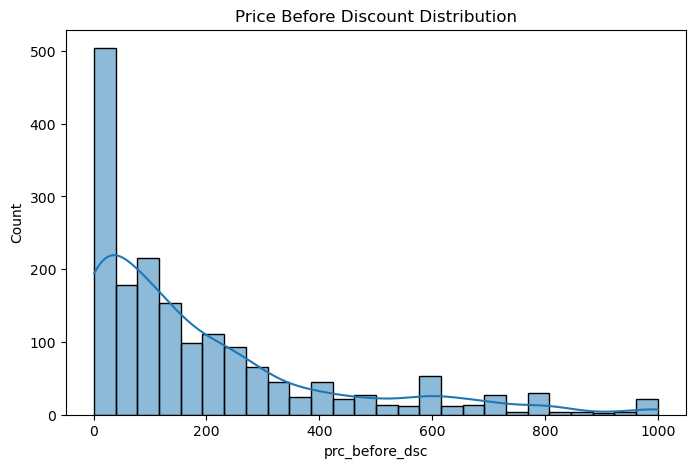

In [57]:
plt.figure(figsize=(8,5))
sns.histplot(data["prc_before_dsc"], kde=True)
plt.title("Price Before Discount Distribution")
plt.show()

# distribution of price after discount

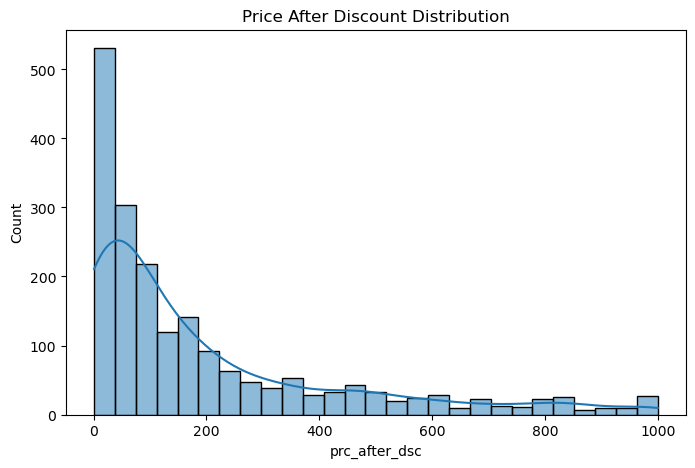

In [58]:
plt.figure(figsize=(8,5))
sns.histplot(data["prc_after_dsc"], kde=True)
plt.title("Price After Discount Distribution")
plt.show()

# distribution of discount percentage

avg dsc percentage is : 34.819718309859155 %


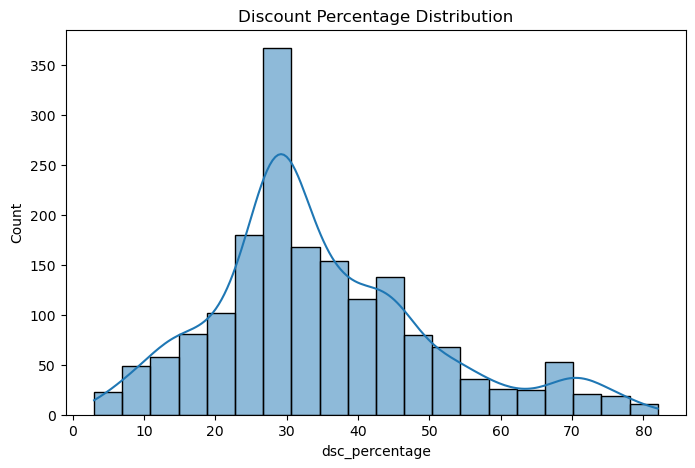

In [59]:
print(f'avg dsc percentage is : {data["dsc_percentage"].mean()} %')
plt.figure(figsize=(8,5))
sns.histplot(data["dsc_percentage"], bins=20, kde=True)
plt.title("Discount Percentage Distribution")
plt.show()

# distribution of product review 

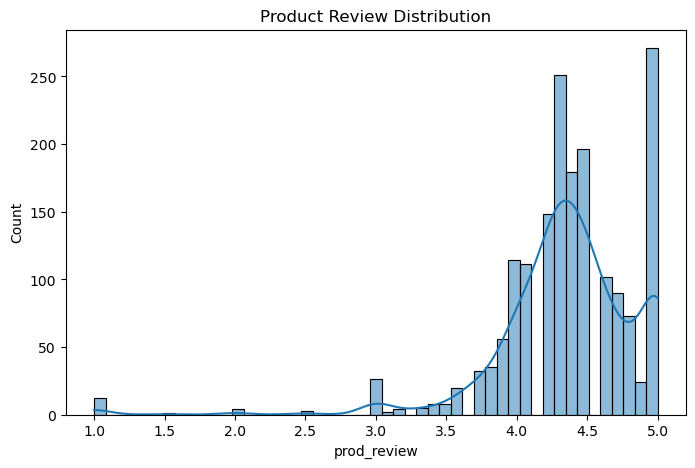

In [60]:
plt.figure(figsize=(8,5))
sns.histplot(data["prod_review"], kde=True)
plt.title("Product Review Distribution")
plt.show()